# 05  -  VM Usage Clustering

Group VMs by usage behavior using K-Means on the 5 VIF-selected features.
Clustering reveals operational archetypes (always-idle, bursty, steady workers)
that go beyond the threshold-based classification in `eda.py`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

sns.set_theme(style="whitegrid", palette="muted")
DATA = Path("../data/clean")

## 1. Load and scale features

In [2]:
summary = pd.read_csv(DATA / "vm_utilization_summary.csv")

# Build same 5 features used in the predictive model
summary["cpu_std"] = summary["cpu_max"] - summary["cpu_min"]
summary["cv"] = np.where(summary["cpu_mean"] > 0,
                         summary["cpu_std"] / summary["cpu_mean"], 0)
summary["trend"] = 0.0  # no daily series in summary

feature_cols = ["cpu_std", "cpu_min", "cpu_median", "trend", "cv"]
X_raw = summary[feature_cols].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
print(f"VMs: {len(X_scaled):,}")
print(f"Features: {feature_cols}")

VMs: 123,363
Features: ['cpu_std', 'cpu_min', 'cpu_median', 'trend', 'cv']


## 2. Elbow + silhouette analysis

Find the optimal number of clusters by looking at inertia (elbow) and silhouette score.

k=2: inertia=53,068  silhouette=0.786


k=3: inertia=34,756  silhouette=0.536


k=4: inertia=26,563  silhouette=0.463


k=5: inertia=20,903  silhouette=0.487


k=6: inertia=17,476  silhouette=0.493


k=7: inertia=14,789  silhouette=0.488


k=8: inertia=12,932  silhouette=0.484


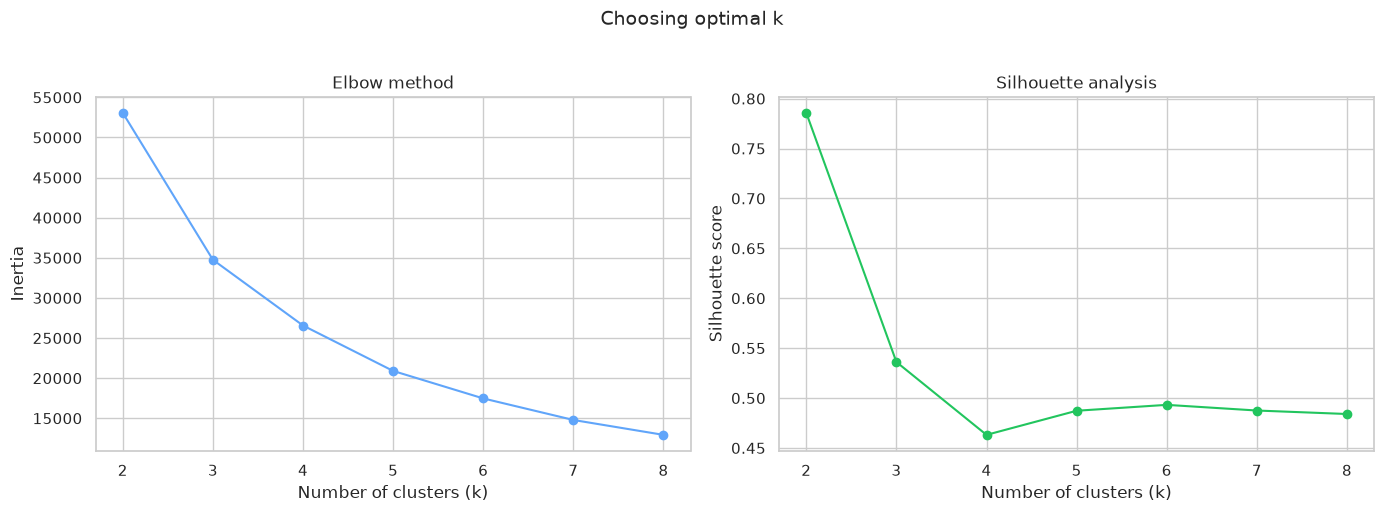


Best k by silhouette: 2


In [3]:
K_RANGE = range(2, 9)
inertias = []
silhouettes = []

# Subsample for speed on 123K VMs
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(X_scaled), size=min(20_000, len(X_scaled)), replace=False)
X_sample = X_scaled[sample_idx]

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = km.fit_predict(X_sample)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_sample, labels, sample_size=5000, random_state=42)
    silhouettes.append(sil)
    print(f"k={k}: inertia={km.inertia_:,.0f}  silhouette={sil:.3f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(list(K_RANGE), inertias, "o-", color="#60A5FA")
ax1.set_xlabel("Number of clusters (k)")
ax1.set_ylabel("Inertia")
ax1.set_title("Elbow method")

ax2.plot(list(K_RANGE), silhouettes, "o-", color="#22C55E")
ax2.set_xlabel("Number of clusters (k)")
ax2.set_ylabel("Silhouette score")
ax2.set_title("Silhouette analysis")

plt.suptitle("Choosing optimal k", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../reports/figures/clustering_elbow.png", dpi=150, bbox_inches="tight")
plt.show()

best_k = list(K_RANGE)[np.argmax(silhouettes)]
print(f"\nBest k by silhouette: {best_k}")

## 3. Fit final model and profile clusters

In [4]:
FINAL_K = best_k
km_final = KMeans(n_clusters=FINAL_K, random_state=42, n_init=10)
summary["cluster"] = km_final.fit_predict(X_scaled)

print(f"Cluster sizes (k={FINAL_K}):")
print(summary["cluster"].value_counts().sort_index())
print()

profile = summary.groupby("cluster").agg(
    n_vms=("instance", "count"),
    cpu_mean_avg=("cpu_mean", "mean"),
    cpu_median_avg=("cpu_median", "mean"),
    cpu_std_avg=("cpu_std", "mean"),
    cv_avg=("cv", "mean"),
    mem_mean_avg=("mem_mean", "mean"),
).round(2)
print("Cluster profiles:")
print(profile.to_string())

Cluster sizes (k=2):
cluster
0    120472
1      2891
Name: count, dtype: int64

Cluster profiles:
          n_vms  cpu_mean_avg  cpu_median_avg  cpu_std_avg  cv_avg  mem_mean_avg
cluster                                                                         
0        120472          6.67            6.62         4.64    0.64         71.71
1          2891         60.85           61.12         6.95    0.12         76.90


In [5]:
# Name clusters by dominant behavior
cluster_names = {}
for c in range(FINAL_K):
    row = profile.loc[c]
    if row["cpu_mean_avg"] < 5:
        cluster_names[c] = "Zombie"
    elif row["cv_avg"] > 1.5:
        cluster_names[c] = "Bursty"
    elif row["cpu_mean_avg"] > 50:
        cluster_names[c] = "Workhorse"
    elif row["cpu_mean_avg"] < 20:
        cluster_names[c] = "Idle"
    else:
        cluster_names[c] = "Moderate"

summary["cluster_name"] = summary["cluster"].map(cluster_names)
print("Cluster naming:")
for c, name in sorted(cluster_names.items()):
    n = (summary["cluster"] == c).sum()
    print(f"  Cluster {c}: {name} ({n:,} VMs)")

Cluster naming:
  Cluster 0: Idle (120,472 VMs)
  Cluster 1: Workhorse (2,891 VMs)


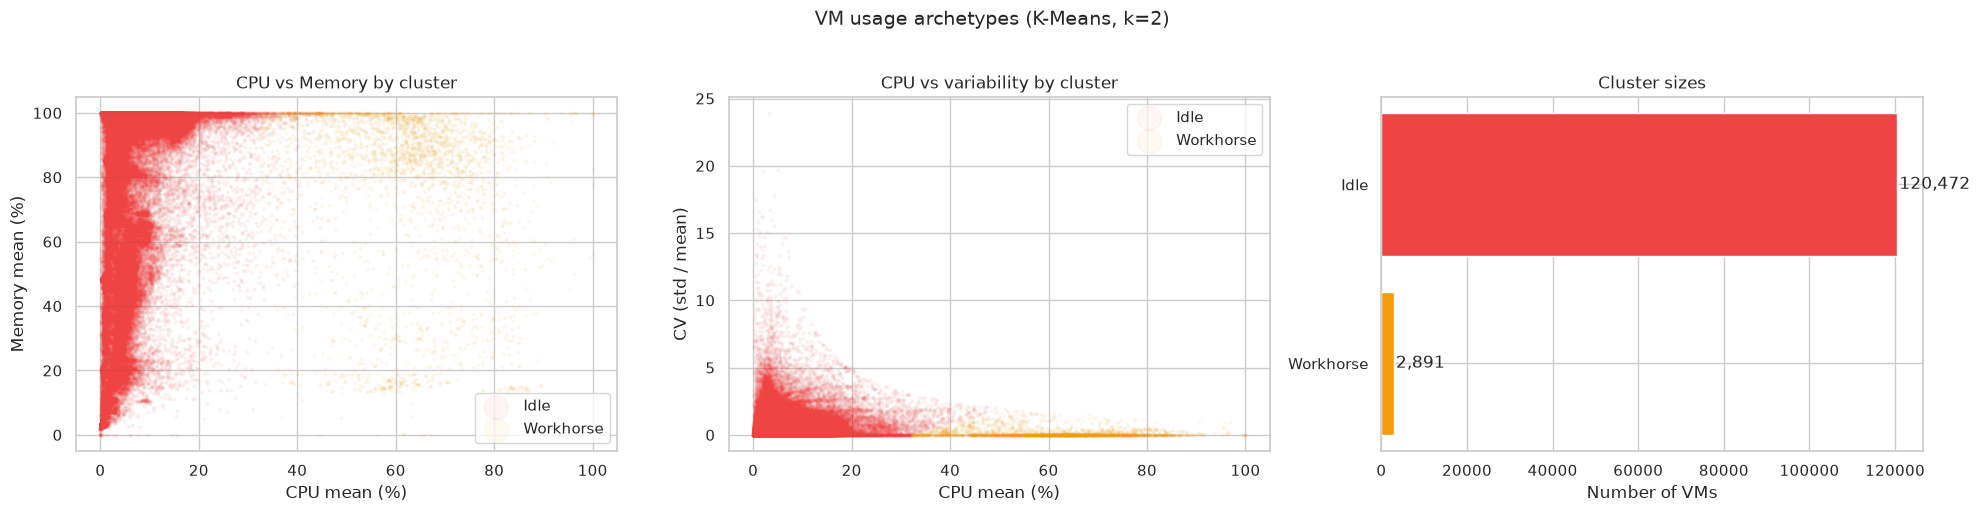

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
colors = ["#EF4444", "#F59E0B", "#22C55E", "#60A5FA", "#A78BFA", "#94A3B8", "#EC4899", "#14B8A6"]

# 1. CPU mean vs memory mean
ax = axes[0]
for c in range(FINAL_K):
    mask = summary["cluster"] == c
    ax.scatter(summary.loc[mask, "cpu_mean"], summary.loc[mask, "mem_mean"],
              alpha=0.05, s=3, color=colors[c], label=cluster_names[c])
ax.set_xlabel("CPU mean (%)")
ax.set_ylabel("Memory mean (%)")
ax.set_title("CPU vs Memory by cluster")
ax.legend(markerscale=10)

# 2. CPU mean vs CV
ax = axes[1]
for c in range(FINAL_K):
    mask = summary["cluster"] == c
    ax.scatter(summary.loc[mask, "cpu_mean"], summary.loc[mask, "cv"],
              alpha=0.05, s=3, color=colors[c], label=cluster_names[c])
ax.set_xlabel("CPU mean (%)")
ax.set_ylabel("CV (std / mean)")
ax.set_title("CPU vs variability by cluster")
ax.legend(markerscale=10)

# 3. Cluster size bar chart
ax = axes[2]
counts = summary["cluster"].value_counts().sort_index()
labels = [cluster_names[c] for c in counts.index]
bar_colors = [colors[c] for c in counts.index]
ax.barh(labels, counts.values, color=bar_colors, edgecolor="white")
for i, v in enumerate(counts.values):
    ax.text(v + 500, i, f"{v:,}", va="center")
ax.set_xlabel("Number of VMs")
ax.set_title("Cluster sizes")
ax.invert_yaxis()

plt.suptitle(f"VM usage archetypes (K-Means, k={FINAL_K})", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../reports/figures/vm_clusters.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
# Cross-reference clusters with existing classification
classified = pd.read_csv(DATA / "vm_classified.csv")
merged = summary[["instance", "cluster_name"]].merge(classified[["instance", "class"]], on="instance", how="inner")

print("Cluster vs classification crosstab:")
ct = pd.crosstab(merged["cluster_name"], merged["class"])
print(ct.to_string())
print()
print("The crosstab shows how rule-based classification (eda.py) aligns")
print("with data-driven clusters. Mismatches suggest VMs where rules and")
print("actual usage patterns diverge -- worth investigating.")

Cluster vs classification crosstab:
class         hot   idle  oversized  review  right-sized  zombie
cluster_name                                                    
Idle            0  70434      33470     288         2781   13499
Workhorse     216      0          0       0         2675       0

The crosstab shows how rule-based classification (eda.py) aligns
with data-driven clusters. Mismatches suggest VMs where rules and
actual usage patterns diverge -- worth investigating.
